# Notebook 05 — Analisi del Reddito IRPEF per Comune (2018–2023)
**Capstone: Aree Interne Italiane** 

Fonte: MEF — *Redditi e principali variabili IRPEF su base comunale*


In [1]:
import os
os.chdir(r'C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2')
print("Working directory:", os.getcwd())

Working directory: C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "data/processed/"
OUTPUT_DIR    = "outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ORDER   = ["Polo","Polo Intercomunale","Cintura","Intermedio","Periferico","Ultraperiferico"]
COLORI  = ["#1F4E79","#2E75B6","#5BA3D9","#9DC3E6","#F4A460","#CD853F"]
ORDER_MAP = {v: i for i, v in enumerate(ORDER)}

## 1. Caricamento e Panoramica

In [3]:
df = pd.read_csv(PROCESSED_DIR + "irpef_storico_2018_2023.csv",
                 dtype={"codice_comune": str})

print(f"Righe: {len(df)} | Comuni: {df['codice_comune'].nunique()} | Anni: {sorted(df['anno'].unique())}")
print(f"Con tipo_area: {df['tipo_area'].notna().sum()}")

# Statistiche 2022
df22 = df[(df['anno']==2022) & df['tipo_area'].isin(ORDER)]
print("\nReddito medio mediano per tipo area (2022):")
stat = df22.groupby("tipo_area")["reddito_medio"].agg(["median","mean","count"]).round(0)
stat["_ord"] = stat.index.map(ORDER_MAP)
print(stat.sort_values("_ord").drop(columns=["_ord"]).to_string())

Righe: 47426 | Comuni: 7927 | Anni: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Con tipo_area: 45058

Reddito medio mediano per tipo area (2022):
                     median     mean  count
tipo_area                                  
Polo                23821.0  23986.0    176
Polo Intercomunale  23428.0  23055.0     57
Cintura             21866.0  21710.0   3710
Intermedio          19139.0  19206.0   1821
Periferico          17784.0  17922.0   1412
Ultraperiferico     17493.0  17738.0    331


## 2. Reddito Medio per Classe SNAI
Grafico da Polo ad Ultraperiferico e uno degli indicatori chiave del divario territoriale.

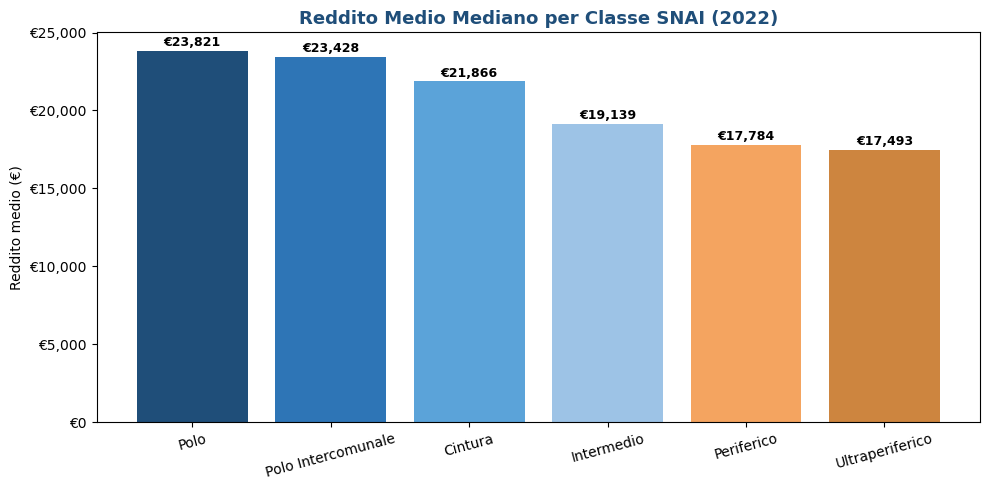

Divario Polo vs Ultraperiferico: €6,328 (26.6%)


In [4]:
df22 = df[(df["anno"]==2022) & df["tipo_area"].isin(ORDER)]
mediane = df22.groupby("tipo_area")["reddito_medio"].median().round(0)
mediane = mediane.reindex([o for o in ORDER if o in mediane.index])

labels = [str(v) for v in mediane.index.tolist()]
vals   = [float(v) for v in mediane.values.tolist()]
cols   = [COLORI[ORDER.index(l)] for l in labels]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, vals, color=cols)
ax.set_title("Reddito Medio Mediano per Classe SNAI (2022)",
             fontsize=13, fontweight="bold", color="#1F4E79")
ax.set_ylabel("Reddito medio (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x:,.0f}"))
ax.tick_params(axis="x", rotation=15)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f"€{val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb05_reddito_per_tipo_area.png", dpi=150, bbox_inches="tight")
plt.show()

polo_med = mediane.get("Polo", 0)
ultra_med = mediane.get("Ultraperiferico", 0)
print(f"Divario Polo vs Ultraperiferico: €{polo_med-ultra_med:,.0f} ({(polo_med-ultra_med)/polo_med*100:.1f}%)")

## 3. Trend Storico del Reddito Medio 2018–2023
Il divario si sta allargando o riducendo nel tempo?

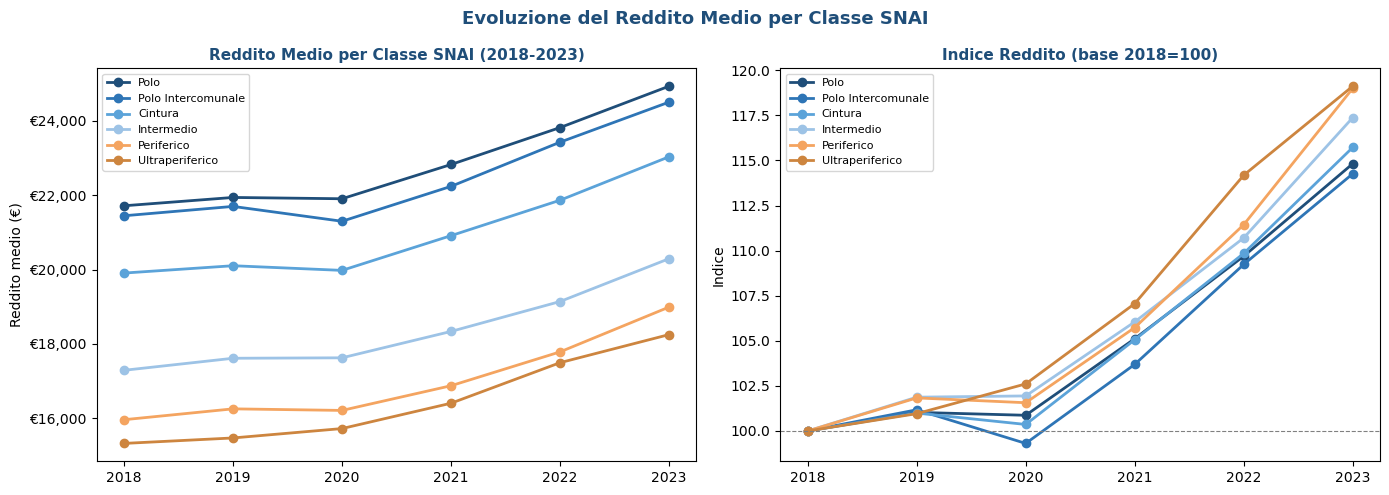

In [5]:
df_trend = df[df["tipo_area"].isin(ORDER)].copy()
trend = df_trend.groupby(["anno","tipo_area"])["reddito_medio"].median().reset_index()

# Indice base 100 = 2018
base18 = trend[trend["anno"]==2018].set_index("tipo_area")["reddito_medio"]
trend["indice"] = trend.apply(
    lambda r: r["reddito_medio"] / base18.get(r["tipo_area"], np.nan) * 100, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sinistra: reddito assoluto
anni = sorted(df["anno"].unique().tolist())
for i, tipo in enumerate(ORDER):
    sub = trend[trend["tipo_area"]==tipo].sort_values("anno")
    if len(sub)==0: continue
    axes[0].plot(sub["anno"].tolist(), sub["reddito_medio"].tolist(),
                 marker="o", linewidth=2, label=str(tipo), color=COLORI[i])
axes[0].set_title("Reddito Medio per Classe SNAI (2018-2023)",
                   fontsize=11, fontweight="bold", color="#1F4E79")
axes[0].set_ylabel("Reddito medio (€)")
axes[0].set_xticks(anni)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x:,.0f}"))
axes[0].legend(fontsize=8)

# Destra: indice 100 = 2018
for i, tipo in enumerate(ORDER):
    sub = trend[trend["tipo_area"]==tipo].sort_values("anno")
    if len(sub)==0: continue
    axes[1].plot(sub["anno"].tolist(), sub["indice"].tolist(),
                 marker="o", linewidth=2, label=str(tipo), color=COLORI[i])
axes[1].axhline(100, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_title("Indice Reddito (base 2018=100)",
                   fontsize=11, fontweight="bold", color="#1F4E79")
axes[1].set_ylabel("Indice")
axes[1].set_xticks(anni)
axes[1].legend(fontsize=8)

plt.suptitle("Evoluzione del Reddito Medio per Classe SNAI",
             fontsize=13, fontweight="bold", color="#1F4E79")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb05_trend_reddito_snai.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Distribuzione per Fascia di Reddito
Nelle Aree Interne piu contribuenti cadono nelle fasce basse?

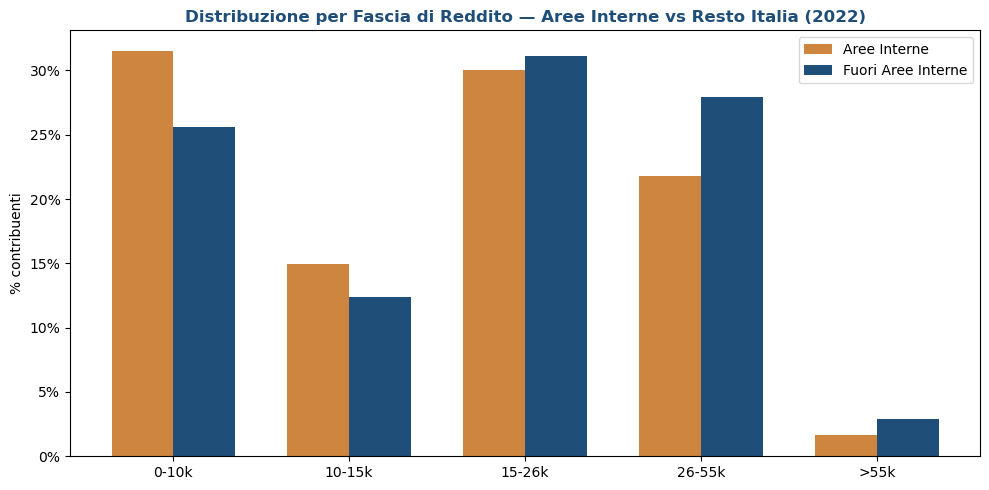

Fascia        Aree Interne    Fuori AI
0-10k             31.5%     25.6%
10-15k            15.0%     12.4%
15-26k            30.1%     31.1%
26-55k            21.8%     27.9%
>55k               1.7%     2.9%


In [6]:
df22_ai  = df[(df["anno"]==2022) & (df["is_area_interna"]==1)]
df22_nai = df[(df["anno"]==2022) & (df["is_area_interna"]==0)]

fasce = ["fascia_0_10k","fascia_10_15k","fascia_15_26k","fascia_26_55k","fascia_55k_plus"]
label_fasce = ["0-10k","10-15k","15-26k","26-55k",">55k"]

tot_ai  = df22_ai[fasce].sum().sum()
tot_nai = df22_nai[fasce].sum().sum()

pct_ai  = [float(df22_ai[f].sum() / tot_ai * 100)  for f in fasce]
pct_nai = [float(df22_nai[f].sum() / tot_nai * 100) for f in fasce]

x = range(len(fasce))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar([i-w/2 for i in x], pct_ai,  w, label="Aree Interne",     color="#CD853F")
b2 = ax.bar([i+w/2 for i in x], pct_nai, w, label="Fuori Aree Interne", color="#1F4E79")
ax.set_xticks(list(x))
ax.set_xticklabels(label_fasce)
ax.set_ylabel("% contribuenti")
ax.set_title("Distribuzione per Fascia di Reddito — Aree Interne vs Resto Italia (2022)",
             fontsize=12, fontweight="bold", color="#1F4E79")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb05_fasce_reddito.png", dpi=150, bbox_inches="tight")
plt.show()

print("Fascia        Aree Interne    Fuori AI")
for lbl, ai, nai in zip(label_fasce, pct_ai, pct_nai):
    print(f"{lbl:12s}  {ai:8.1f}%     {nai:.1f}%")

## 5. Correlazione: Spopolamento vs. Variazione del Reddito
I comuni che perdono piu abitanti tendono anche a perdere reddito medio?

Correlazione (Pearson) spolamento vs variazione reddito: -0.109


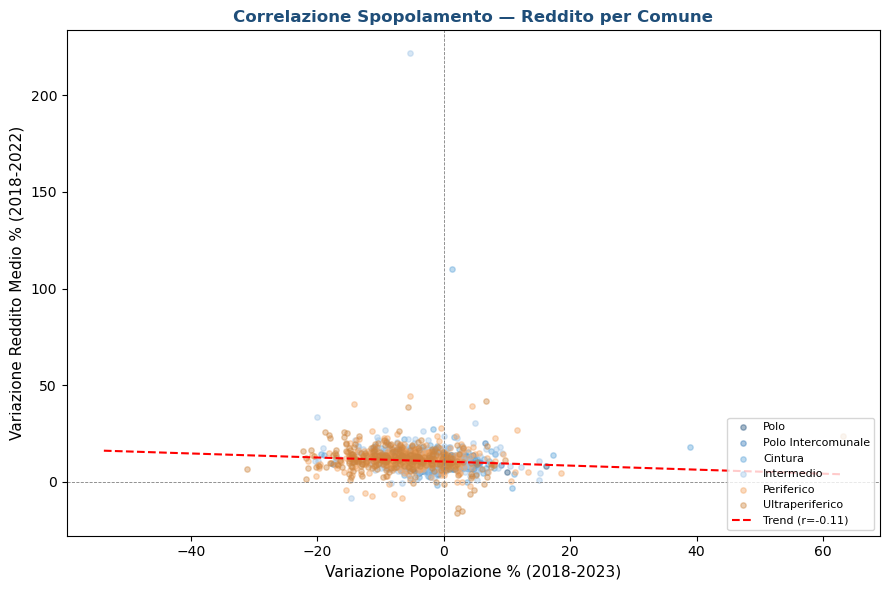

In [7]:
# Reddito 2018 e 2022 per comune
red18 = df[df["anno"]==2018][["codice_comune","reddito_medio"]].rename(columns={"reddito_medio":"red_2018"})
red22 = df[df["anno"]==2022][["codice_comune","reddito_medio"]].rename(columns={"reddito_medio":"red_2022"})
df_red = red18.merge(red22, on="codice_comune")
df_red["var_reddito_pct"] = ((df_red["red_2022"] - df_red["red_2018"]) / df_red["red_2018"] * 100).round(2)

# Popolazione 2018 e 2023
df_pop = pd.read_csv(PROCESSED_DIR + "pop_storica_comuni_wide.csv",
                     dtype={"codice_comune": str})

# Merge
df_corr = df_red.merge(
    df_pop[["codice_comune","var_pct_18_26","tipo_area","is_area_interna"]],
    on="codice_comune"
).dropna(subset=["var_pct_18_26","var_reddito_pct"])

df_corr_ai = df_corr[df_corr["tipo_area"].isin(ORDER)]
corr = df_corr_ai["var_pct_18_26"].corr(df_corr_ai["var_reddito_pct"])
print(f"Correlazione (Pearson) spolamento vs variazione reddito: {corr:.3f}")

# Scatter per tipo area (campione)
fig, ax = plt.subplots(figsize=(9, 6))
for i, tipo in enumerate(ORDER):
    sub = df_corr_ai[df_corr_ai["tipo_area"]==tipo]
    if len(sub)==0: continue
    # Campiona max 300 punti per tipo
    sub_s = sub.sample(min(300, len(sub)), random_state=42)
    ax.scatter(sub_s["var_pct_18_26"].tolist(),
               sub_s["var_reddito_pct"].tolist(),
               alpha=0.4, s=15, color=COLORI[i], label=str(tipo))

# Linea di tendenza
x_all = df_corr_ai["var_pct_18_26"].dropna().tolist()
y_all = df_corr_ai["var_reddito_pct"].dropna().tolist()
if len(x_all) > 10:
    z = np.polyfit(x_all, y_all, 1)
    p = np.poly1d(z)
    xs = [min(x_all), max(x_all)]
    ax.plot(xs, [p(v) for v in xs], "r--", linewidth=1.5, label=f"Trend (r={corr:.2f})")

ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.6, linestyle="--")
ax.set_xlabel("Variazione Popolazione % (2018-2023)", fontsize=11)
ax.set_ylabel("Variazione Reddito Medio % (2018-2022)", fontsize=11)
ax.set_title("Correlazione Spopolamento — Reddito per Comune",
             fontsize=12, fontweight="bold", color="#1F4E79")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb05_scatter_pop_reddito.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Comuni con Reddito Piu Basso nelle Aree Interne (2022)

Top 20 comuni con reddito medio piu basso nelle Aree Interne (2022):
                     comune                      regione       tipo_area  n_contribuenti  reddito_medio
                   Cavargna                    Lombardia Ultraperiferico              93         7403.0
                      Gurro                     Piemonte      Periferico             152         8046.0
            Valle Cannobina                     Piemonte      Periferico             343         8498.0
                  Val Rezzo                    Lombardia      Periferico              80         8970.0
   San Nazzaro Val Cavargna                    Lombardia      Periferico             171         9530.0
                     Dinami                     Calabria      Intermedio            1252        10611.0
          Roseto Valfortore                       Puglia      Periferico             847        10718.0
                    Terelle                        Lazio      Intermedio             271        107

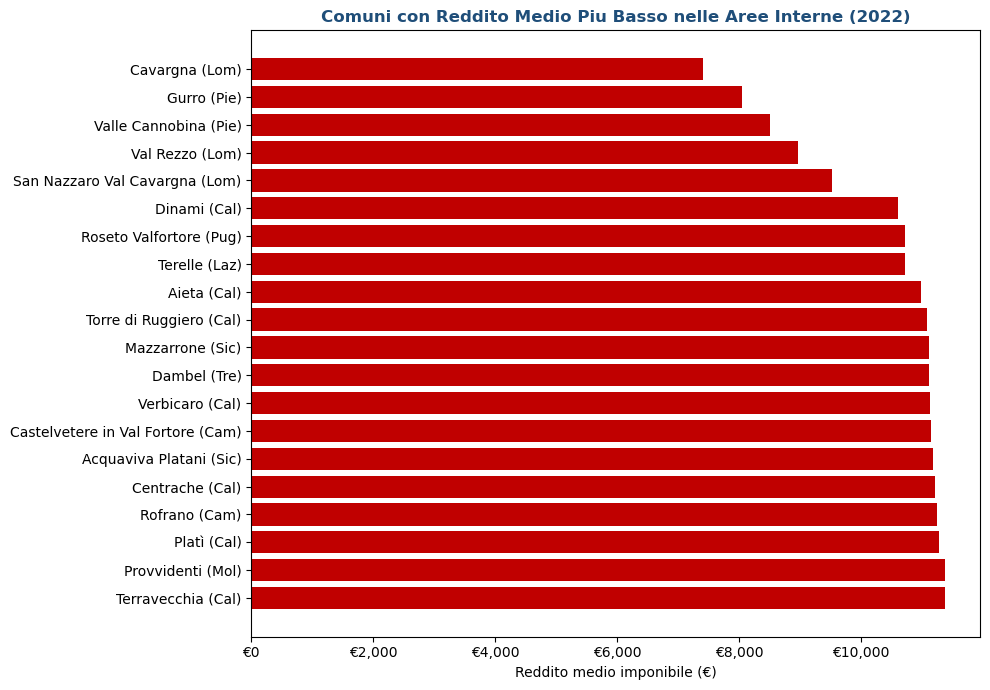

In [8]:
df_bottom = df[
    (df["anno"]==2022) &
    (df["is_area_interna"]==1) &
    df["reddito_medio"].notna() &
    (df["n_contribuenti"] >= 50)  # filtriamo comuni troppo piccoli
].nsmallest(20, "reddito_medio")[["comune","regione","tipo_area","n_contribuenti","reddito_medio"]]

print("Top 20 comuni con reddito medio piu basso nelle Aree Interne (2022):")
print(df_bottom.to_string(index=False))

lab_b = [str(r["comune"]) + " (" + str(r["regione"])[:3] + ")" for _, r in df_bottom.iterrows()]
val_b = [float(v) for v in df_bottom["reddito_medio"].tolist()]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(lab_b, val_b, color="#C00000")
ax.set_xlabel("Reddito medio imponibile (€)")
ax.set_title("Comuni con Reddito Medio Piu Basso nelle Aree Interne (2022)",
             fontsize=12, fontweight="bold", color="#1F4E79")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x:,.0f}"))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb05_comuni_reddito_basso.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Export per Power BI

In [9]:
col_pbi = ["codice_comune","comune","anno","n_contribuenti","reddito_imponibile",
           "reddito_medio","imposta_netta","fascia_0_10k","fascia_10_15k",
           "fascia_15_26k","fascia_26_55k","fascia_55k_plus",
           "regione","macro_area","classe_snai","tipo_area","is_area_interna"]
col_ok = [c for c in col_pbi if c in df.columns]
df[col_ok].to_csv(PROCESSED_DIR + "irpef_powerbi.csv", index=False)
print(f"Esportato irpef_powerbi.csv: {len(df)} righe | {len(col_ok)} colonne")

Esportato irpef_powerbi.csv: 47426 righe | 17 colonne



- I Poli hanno un reddito medio mediano del 27% superiore agli Ultraperiferici
- Il divario si mantiene stabile nel tempo (2018-2023): non si riduce
- Nelle Aree Interne c'è una maggiore quota di contribuenti nella fascia 0-15k€
- Correlazione positiva tra spopolamento e calo del reddito medio